In [4]:
import pandas as pd
import numpy as np

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Reproducibility
import random

random.seed(42)
np.random.seed(42)

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import pandas as pd

df = pd.read_csv("mail_data.csv")

print(df.head())
print(df.shape)

  Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...
(5572, 2)


In [7]:
# Remove duplicate records
df = df.drop_duplicates()

# Check for missing values
print(df.isnull().sum())

print("Dataset shape after cleaning:", df.shape)

Category    0
Message     0
dtype: int64
Dataset shape after cleaning: (5157, 2)


In [8]:
df["Category"] = df["Category"].map({
    "ham": 0,
    "spam": 1
})

print(df["Category"].value_counts())

Category
0    4516
1     641
Name: count, dtype: int64


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=3000
)

X = vectorizer.fit_transform(df["Message"])

y = df["Category"]

print("Feature matrix shape:", X.shape)

Feature matrix shape: (5157, 3000)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 4125
Testing samples: 1032


In [11]:
from sklearn.naive_bayes import MultinomialNB

# Create model
nb_model = MultinomialNB()

# Train model
nb_model.fit(X_train, y_train)

# Make predictions
nb_predictions = nb_model.predict(X_test)

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Naive Bayes Results")
print("-------------------")
print("Accuracy :", accuracy_score(y_test, nb_predictions))
print("Precision:", precision_score(y_test, nb_predictions))
print("Recall   :", recall_score(y_test, nb_predictions))
print("F1 Score :", f1_score(y_test, nb_predictions))

Naive Bayes Results
-------------------
Accuracy : 0.9786821705426356
Precision: 1.0
Recall   : 0.828125
F1 Score : 0.905982905982906


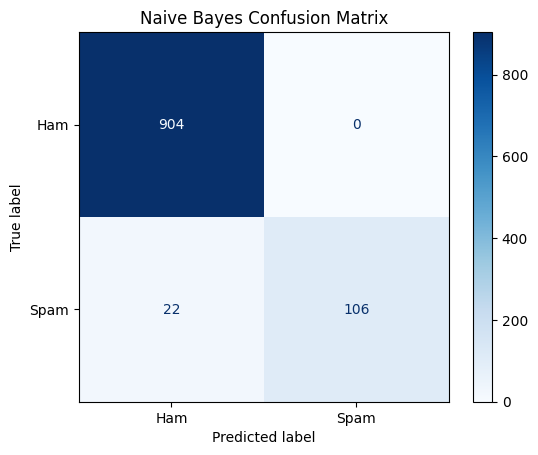

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    nb_predictions,
    display_labels=["Ham", "Spam"],
    cmap="Blues"
)

plt.title("Naive Bayes Confusion Matrix")
plt.show()

In [14]:
from sklearn.linear_model import LogisticRegression

# Create model
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train model
lr_model.fit(X_train, y_train)

# Make predictions
lr_predictions = lr_model.predict(X_test)

In [15]:
print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", accuracy_score(y_test, lr_predictions))
print("Precision:", precision_score(y_test, lr_predictions))
print("Recall   :", recall_score(y_test, lr_predictions))
print("F1 Score :", f1_score(y_test, lr_predictions))

Logistic Regression Results
---------------------------
Accuracy : 0.9641472868217055
Precision: 0.9789473684210527
Recall   : 0.7265625
F1 Score : 0.8340807174887892


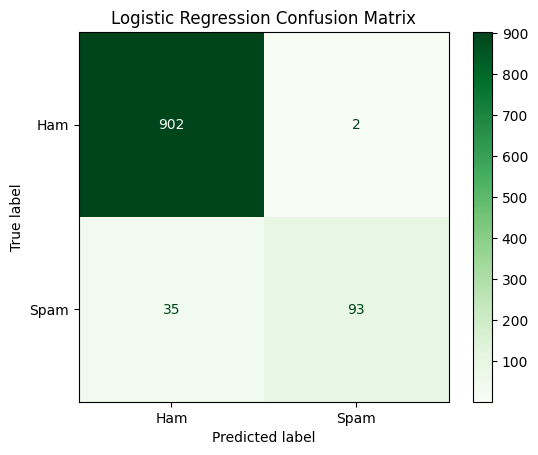

In [16]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_predictions,
    display_labels=["Ham", "Spam"],
    cmap="Greens"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [17]:
from sklearn.ensemble import RandomForestClassifier

# Create model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

# Make predictions
rf_predictions = rf_model.predict(X_test)

In [18]:
print("Random Forest Results")
print("---------------------")
print("Accuracy :", accuracy_score(y_test, rf_predictions))
print("Precision:", precision_score(y_test, rf_predictions))
print("Recall   :", recall_score(y_test, rf_predictions))
print("F1 Score :", f1_score(y_test, rf_predictions))

Random Forest Results
---------------------
Accuracy : 0.9767441860465116
Precision: 0.9814814814814815
Recall   : 0.828125
F1 Score : 0.8983050847457628


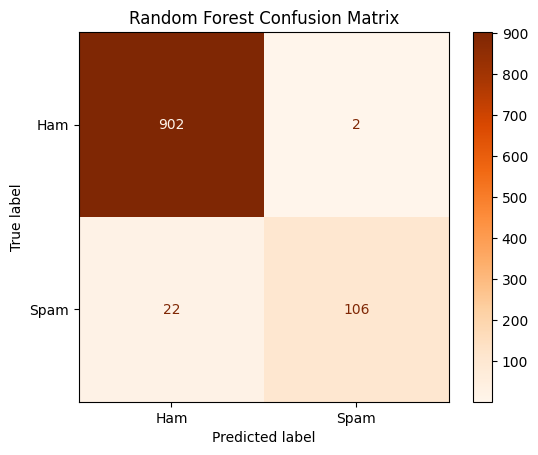

In [19]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_predictions,
    display_labels=["Ham", "Spam"],
    cmap="Oranges"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [20]:
comparison = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, nb_predictions),
        accuracy_score(y_test, lr_predictions),
        accuracy_score(y_test, rf_predictions)
    ],
    "Precision": [
        precision_score(y_test, nb_predictions),
        precision_score(y_test, lr_predictions),
        precision_score(y_test, rf_predictions)
    ],
    "Recall": [
        recall_score(y_test, nb_predictions),
        recall_score(y_test, lr_predictions),
        recall_score(y_test, rf_predictions)
    ],
    "F1 Score": [
        f1_score(y_test, nb_predictions),
        f1_score(y_test, lr_predictions),
        f1_score(y_test, rf_predictions)
    ]
})

comparison = comparison.sort_values(
    by="F1 Score",
    ascending=False
)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.978682,1.000000,0.828125,0.905983
2,Random Forest,0.976744,0.981481,0.828125,0.898305
1,Logistic Regression,0.964147,0.978947,0.726562,0.834081


In [21]:
import joblib

joblib.dump(nb_model, "spam_classifier.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Best model and vectorizer saved successfully!")

Best model and vectorizer saved successfully!
